In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler,StandardScaler
# Preprocessing
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Imbalance Handling
from imblearn.over_sampling import SMOTE

# Model Saving
import joblib

In [50]:
df = pd.read_csv("../data/raw/Churn_Modelling.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [51]:
print("\n Dataset Info:\n")
print(df.info())


 Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB
None


In [52]:
print("\nSummary statistics (numerical):")
df.describe().transpose()


Summary statistics (numerical):


,count,mean,std,min,25%,50%,75%,max
RowNumber,10000.0,5.000500e+03,2886.895680,1.00,2500.75,5.000500e+03,7.500250e+03,10000.00
CustomerId,10000.0,1.569094e+07,71936.186123,15565701.00,15628528.25,1.569074e+07,1.575323e+07,15815690.00
CreditScore,10000.0,6.505288e+02,96.653299,350.00,584.00,6.520000e+02,7.180000e+02,850.00
Age,10000.0,3.892180e+01,10.487806,18.00,32.00,3.700000e+01,4.400000e+01,92.00
Tenure,10000.0,5.012800e+00,2.892174,0.00,3.00,5.000000e+00,7.000000e+00,10.00
Balance,10000.0,7.648589e+04,62397.405202,0.00,0.00,9.719854e+04,1.276442e+05,250898.09
NumOfProducts,10000.0,1.530200e+00,0.581654,1.00,1.00,1.000000e+00,2.000000e+00,4.00
HasCrCard,10000.0,7.055000e-01,0.455840,0.00,0.00,1.000000e+00,1.000000e+00,1.00
IsActiveMember,10000.0,5.151000e-01,0.499797,0.00,0.00,1.000000e+00,1.000000e+00,1.00
EstimatedSalary,10000.0,1.000902e+05,57510.492818,11.58,51002.11,1.001939e+05,1.493882e+05,199992.48


In [53]:
print(f"\n Dataset Shape: {df.shape}")


 Dataset Shape: (10000, 14)


In [54]:
# Check for missing values
print("\n Missing Values:\n")
print(df.isna().sum())


 Missing Values:

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


In [55]:
#Check for duplicate

duplicate_rows=df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")

Number of duplicate rows: 0


In [56]:
# drop the columns RowNumber,CustomerId and surname as it do not influence churn
df.drop(["RowNumber", "CustomerId", "Surname"], axis=1, inplace=True)

In [57]:
# Shape of dataset after removing unwanted columns
print(f"\n Dataset Shape: {df.shape}")


 Dataset Shape: (10000, 11)


In [58]:
# numerical Columns
num_cols=df.select_dtypes(include=['int64','float64']).columns
num_cols.tolist()


['CreditScore',
 'Age',
 'Tenure',
 'Balance',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember',
 'EstimatedSalary',
 'Exited']

In [59]:
# Categorical Columns
cat_cols=df.select_dtypes(include=['object']).columns
cat_cols.tolist()

['Geography', 'Gender']

In [60]:
# Check for wrong values
print(f"\nUnique values in categorical columns:")
print(f"Geography: {df['Geography'].unique()}")
print(f"Gender: {df['Gender'].unique()}")
print(f"NumOfProducts: {sorted(df['NumOfProducts'].unique())}")


Unique values in categorical columns:
Geography: ['France' 'Spain' 'Germany']
Gender: ['Female' 'Male']
NumOfProducts: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


In [61]:
# Check for impossible values
print(f"\nValue Ranges:")
print(f"Age: {df['Age'].min()} to {df['Age'].max()}")
print(f"CreditScore: {df['CreditScore'].min()} to {df['CreditScore'].max()}")
print(f"Balance: {df['Balance'].min()} to {df['Balance'].max()}")


Value Ranges:
Age: 18 to 92
CreditScore: 350 to 850
Balance: 0.0 to 250898.09


In [62]:
#Check statistical values for fields with other than numerical datatype
df.describe(exclude=np.number).T

,count,unique,top,freq
Geography,10000,3,France,5014
Gender,10000,2,Male,5457


In [63]:
#Key Findings:
#Clean Data: The dataset has no missing values, so we can analyze it without any data gaps.

#No wrong values in categorical columns

#Geography: France, Spain, Germany (3 countries)

#Gender: Male, Female (properly encoded)

#NumOfProducts: 1-4 products per customer

#All values within reasonable ranges

#Removing Unnecessary Columns: We are dropping the columns 'RowNumber', 'CustomerId', and 'Surname' from the dataset as they uniquely identify each customer and do not provide any relevant information for building the customer churn model. Removing these columns allows us to focus on the meaningful features that contribute to predicting churn and improve the efficiency of our analysis.

#Target Variable: The column “Exited” is our main focus, as it tells us whether a customer has churned or not. This will be used to train the prediction model.

In [64]:
outlier_summary = {}
outlier_col=num_cols.drop('Exited')
for col in outlier_col:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)][col]

    outlier_summary[col] = {
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower Bound': lower,
        'Upper Bound': upper,
        'Outlier Count': len(outliers)
    }

pd.DataFrame(outlier_summary).T

,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
CreditScore,584.00,718.0000,134.0000,383.00000,919.00000,15.0
Age,32.00,44.0000,12.0000,14.00000,62.00000,359.0
Tenure,3.00,7.0000,4.0000,-3.00000,13.00000,0.0
Balance,0.00,127644.2400,127644.2400,-191466.36000,319110.60000,0.0
NumOfProducts,1.00,2.0000,1.0000,-0.50000,3.50000,60.0
HasCrCard,0.00,1.0000,1.0000,-1.50000,2.50000,0.0
IsActiveMember,0.00,1.0000,1.0000,-1.50000,2.50000,0.0
EstimatedSalary,51002.11,149388.2475,98386.1375,-96577.09625,296967.45375,0.0


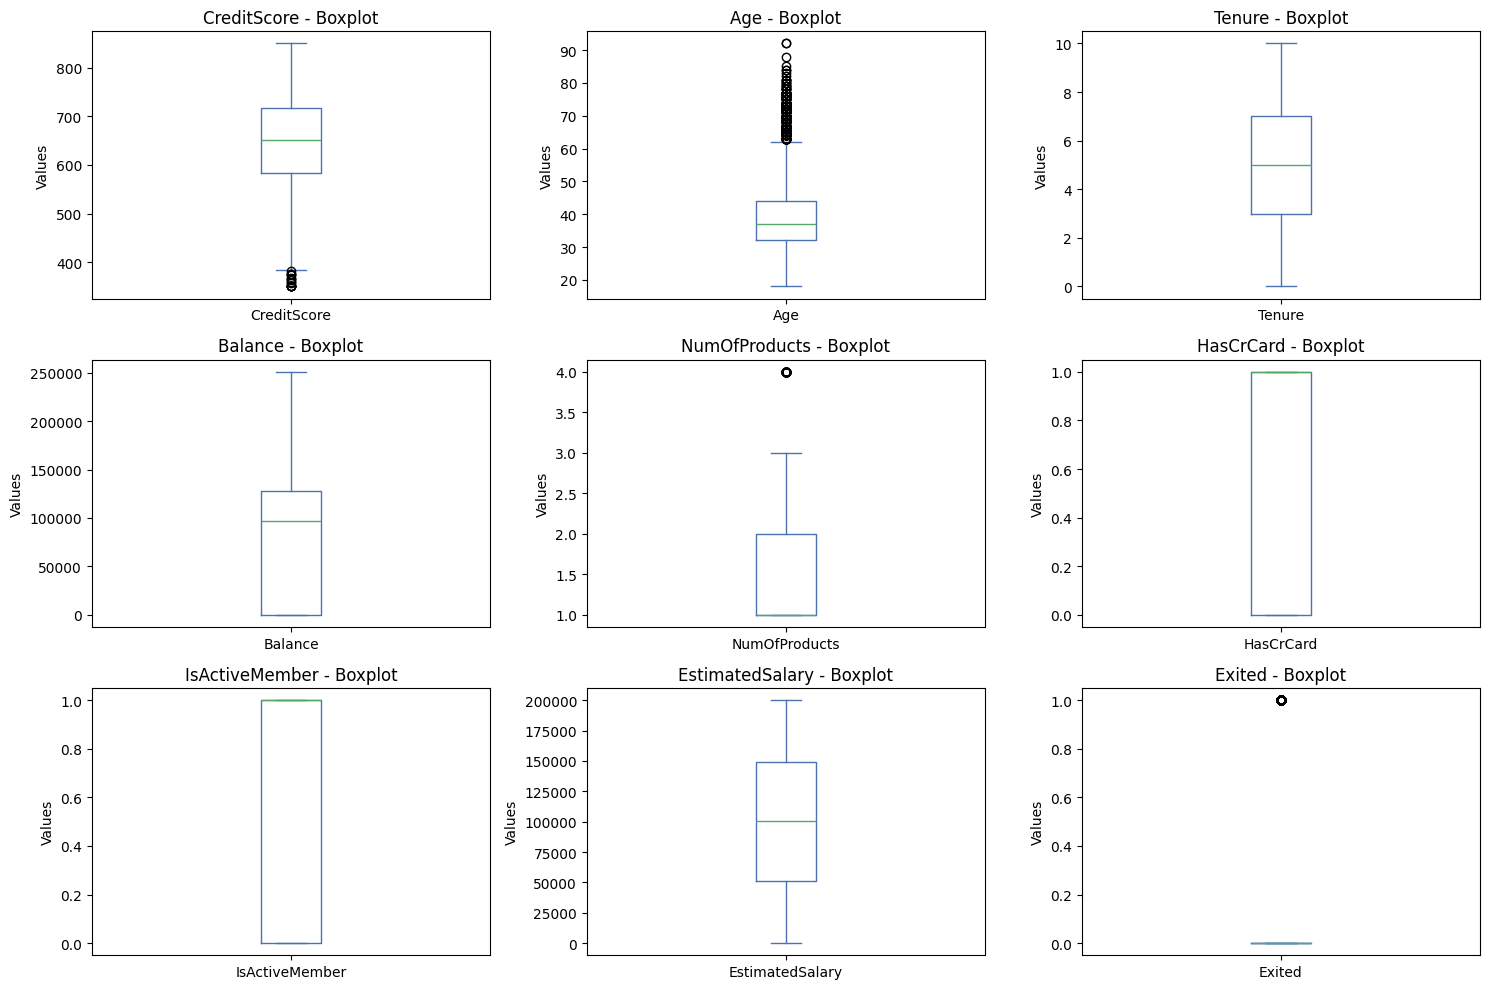

In [65]:
# Visualize outliers
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.ravel()

for i, col in enumerate(num_cols):
    df[col].plot(kind='box', ax=axes[i], title=f'{col} - Boxplot')
    axes[i].set_ylabel('Values')

plt.tight_layout()
plt.show()

In [66]:
#Key Findings:
#Outlier detection was performed using the Interquartile Range (IQR) method. The IQR method mathematically identifies values that fall below:

#Lower Bound = Q1 – 1.5 × IQR

#Upper Bound = Q3 + 1.5 × IQR

#Here we do not remove or cap any outliers, for the reasons explained below:

#Outlier analysis was performed using the IQR method. Although some features such as CreditScore, Age, and NumOfProducts showed statistical outliers, these values were retained because they represent genuine customer behavior rather than data errors.

#In a banking dataset, high-value customers, older customers, and low/high credit score customers are crucial segments that significantly influence churn behavior. Removing or capping these values would lead to loss of meaningful information, distort model learning, and reduce real-world applicability.

#Therefore, no outliers were removed, as all identified extreme values are valid business observations and important for accurate churn prediction.

In [67]:
df['BalanceSalaryRatio'] = (df['Balance'] / (df['EstimatedSalary'] + 1)).round(3)

In [68]:
df["TenureAgeRatio"] = df["Tenure"] / (df["Age"] + 1)

In [69]:
df['ProductUtilizationRate'] = (df['NumOfProducts'] / (df['Tenure'] + 1)).round(3)

In [70]:
df["AgeBalanceInteraction"] = df["Age"] * df["Balance"]

In [71]:
df['EngagementScore'] = (
    df['IsActiveMember'] +
    df['HasCrCard'] +
    (df['NumOfProducts'] / df['NumOfProducts'].max())
).round(2)

In [72]:
df['CreditScoreCategory'] = pd.cut(df['CreditScore'], 
                                   bins=[0, 500, 700, 850], 
                                   labels=[2, 1, 0]).astype(int)

In [73]:
np.random.seed(42)
df['ComplaintCount'] = np.random.poisson(lam=0.5, size=len(df))

In [74]:
# Shape of dataset after feature engineering
print(f"\n Dataset Shape: {df.shape}")


 Dataset Shape: (10000, 18)


In [75]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,BalanceSalaryRatio,TenureAgeRatio,ProductUtilizationRate,AgeBalanceInteraction,EngagementScore,CreditScoreCategory,ComplaintCount
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,0.000,0.046512,0.333,0.00,2.25,1,0
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,0.745,0.023810,0.500,3436122.26,1.25,1,2
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1.401,0.186047,0.333,6705753.60,1.75,1,0
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0.000,0.025000,1.000,0.00,0.50,1,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,1.587,0.045455,0.333,5396965.26,2.25,0,0


In [76]:
#Distribution
# since it is 80% and 20%, it is imbalanced data. We need to SMOTE the dataset after splitting for training purpose
churn_dist = df['Exited'].value_counts(normalize=True) * 100
print("\nClass distribution (%):")
print(churn_dist)


Class distribution (%):
Exited
0    79.63
1    20.37
Name: proportion, dtype: float64


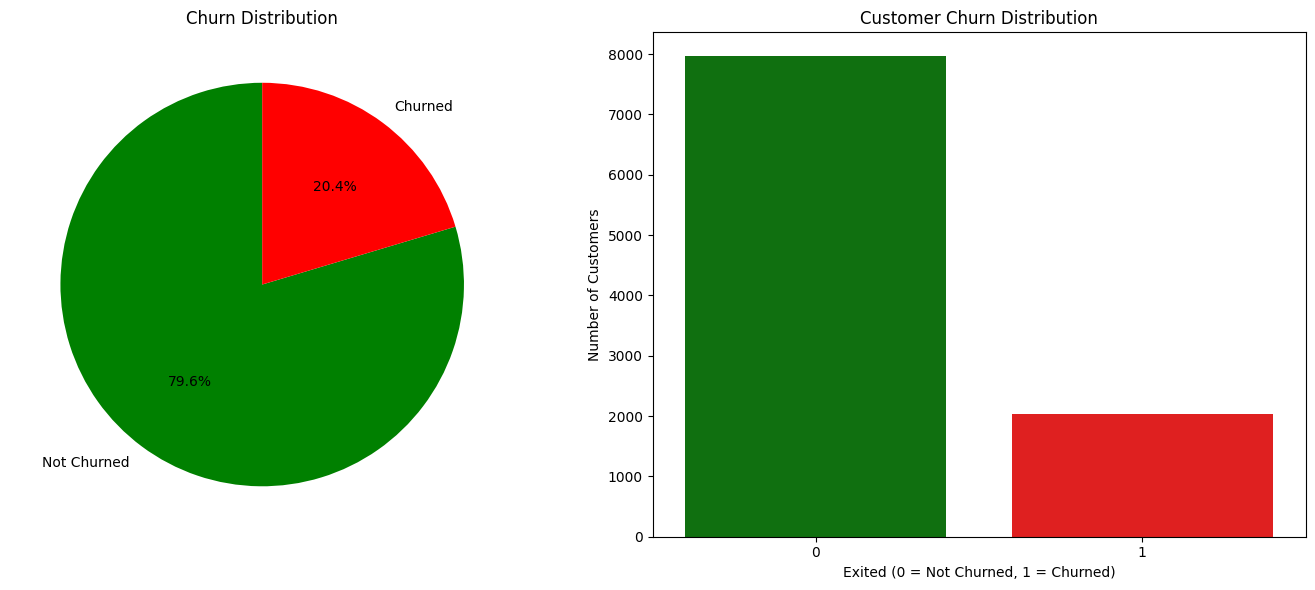

In [77]:
# Define colors (same order as value_counts: 0 then 1)
colors = ['green', 'red']

plt.figure(figsize=(14, 6))

# --- Left plot: Pie chart ---
plt.subplot(1, 2, 1)
churn_counts = df['Exited'].value_counts().sort_index()  # ensures 0 then 1
plt.pie(
    churn_counts.values,
    labels=['Not Churned', 'Churned'],
    autopct='%1.1f%%',
    startangle=90,
    colors=colors
)
plt.title('Churn Distribution')

# --- Right plot: Countplot (fixed version) ---
plt.subplot(1, 2, 2)

# Option A: Use hue parameter (recommended)
sns.countplot(
    data=df,
    x='Exited',
    hue='Exited',  # Add hue parameter
    palette=colors,
    legend=False  # Hide legend since x-axis already shows categories
)

# Option B: Alternative using matplotlib (no seaborn warning)
"""
churn_counts = df['Exited'].value_counts().sort_index()
plt.bar(['Not Churned', 'Churned'], churn_counts.values, color=colors)
"""

plt.xlabel('Exited (0 = Not Churned, 1 = Churned)')
plt.ylabel('Number of Customers')
plt.title('Customer Churn Distribution')

plt.tight_layout()
plt.show()

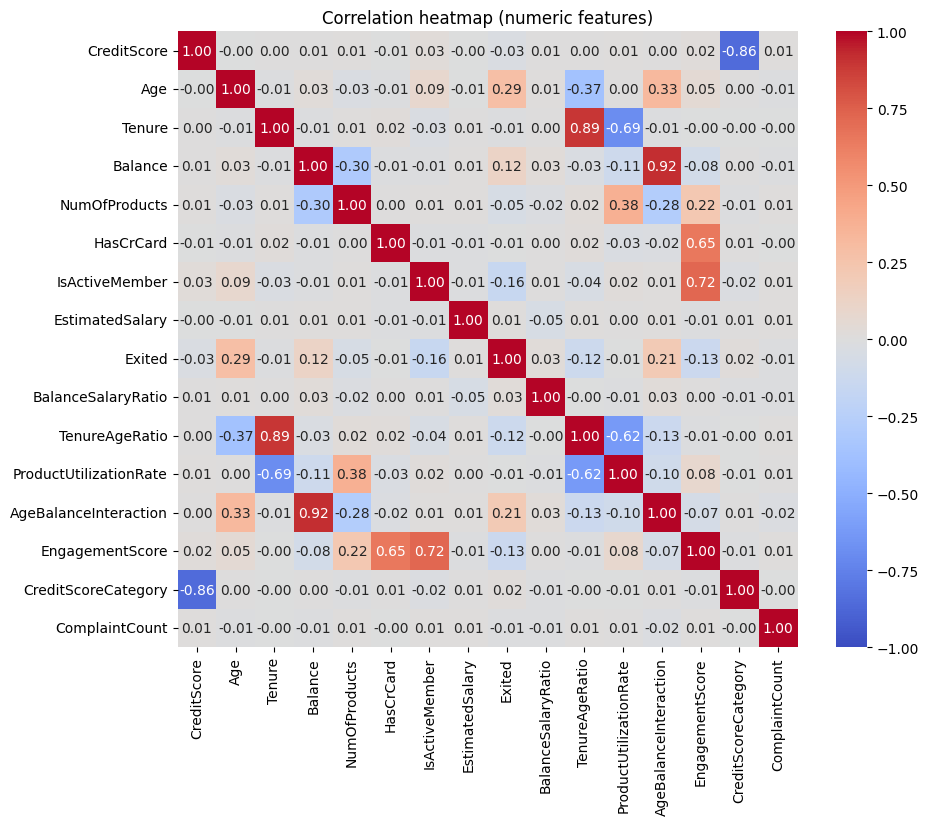

In [78]:
plt.figure(figsize=(10,8))
num_for_corr = df.select_dtypes(include=[np.number])
corr = num_for_corr.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation heatmap (numeric features)")
plt.show()

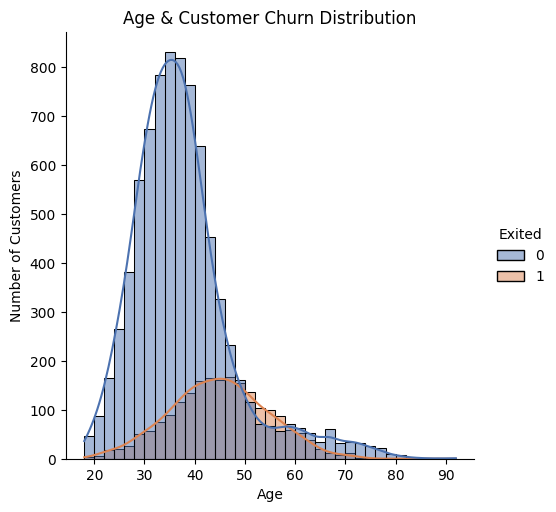

In [79]:
palette = "deep"
sns.set_palette(palette)

sns.displot(data=df, x='Age', hue='Exited',kde=True, bins=37)

plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.title('Age & Customer Churn Distribution')

plt.show()

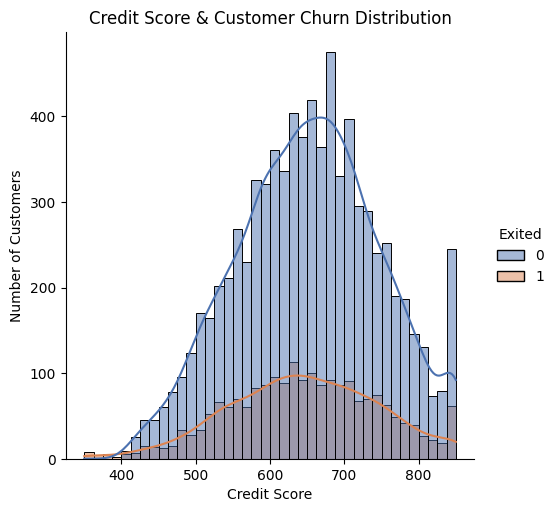

In [80]:
palette = "deep"
sns.set_palette(palette)

sns.displot(data=df, x='CreditScore',hue='Exited', kde=True, bins=40)

plt.xlabel('Credit Score')
plt.ylabel('Number of Customers')
plt.title('Credit Score & Customer Churn Distribution')

plt.show()

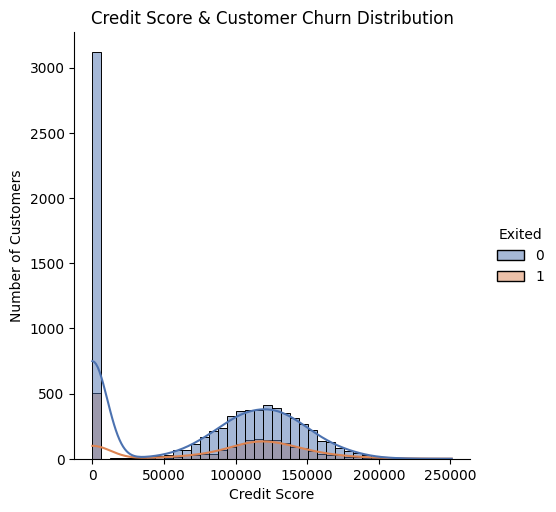

In [81]:
palette = "deep"
sns.set_palette(palette)

sns.displot(data=df, x='Balance',hue='Exited', kde=True, bins=40)

plt.xlabel('Credit Score')
plt.ylabel('Number of Customers')
plt.title('Credit Score & Customer Churn Distribution')

plt.show()

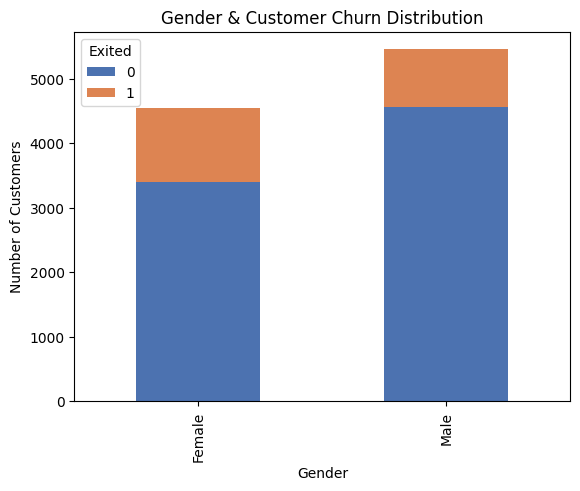

In [82]:
palette = "deep"
sns.set_palette(palette)

pd.crosstab(df['Gender'], df['Exited']).plot(kind='bar', stacked=True)

plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.title('Gender & Customer Churn Distribution')

plt.show()

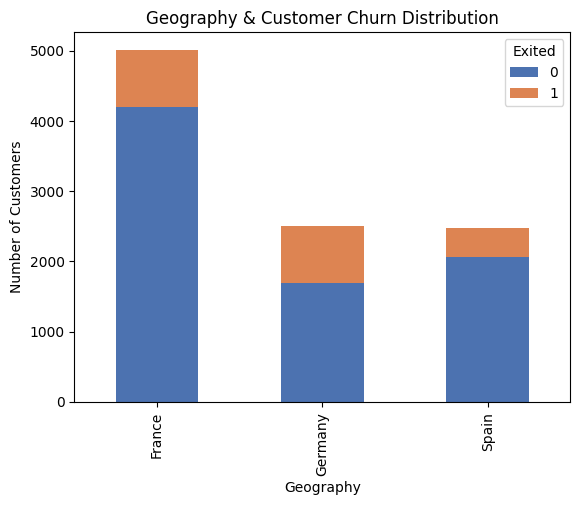

In [83]:
palette = "deep"
sns.set_palette(palette)

pd.crosstab(df['Geography'], df['Exited']).plot(kind='bar', stacked=True)

plt.xlabel('Geography')
plt.ylabel('Number of Customers')
plt.title('Geography & Customer Churn Distribution')

plt.show()

In [84]:
df['Geography'] = df['Geography'].map({
    'France': 0,
    'Germany': 1,
    'Spain': 2
})

df['Gender'] = df['Gender'].map({
    'Male': 0,
    'Female': 1
})

In [85]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,BalanceSalaryRatio,TenureAgeRatio,ProductUtilizationRate,AgeBalanceInteraction,EngagementScore,CreditScoreCategory,ComplaintCount
0,619,0,1,42,2,0.00,1,1,1,101348.88,1,0.000,0.046512,0.333,0.00,2.25,1,0
1,608,2,1,41,1,83807.86,1,0,1,112542.58,0,0.745,0.023810,0.500,3436122.26,1.25,1,2
2,502,0,1,42,8,159660.80,3,1,0,113931.57,1,1.401,0.186047,0.333,6705753.60,1.75,1,0
3,699,0,1,39,1,0.00,2,0,0,93826.63,0,0.000,0.025000,1.000,0.00,0.50,1,0
4,850,2,1,43,2,125510.82,1,1,1,79084.10,0,1.587,0.045455,0.333,5396965.26,2.25,0,0


In [86]:
# Separate features and target
X = df.drop("Exited", axis=1)
y = df["Exited"]

In [87]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [96]:
print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"Training features shape: {X_train.shape}")
print(f"Test features shape: {X_test.shape}")



Training set size: 8000
Test set size: 2000
Training features shape: (8000, 17)
Test features shape: (2000, 17)


In [88]:
# Separate features that need scaling from binary features
binary_features = ['Geography', 'Gender', 'HasCrCard', 'IsActiveMember', 
                   'CreditScoreCategory']
continuous_features = [col for col in X_train.columns if col not in binary_features]


In [89]:
print("\nContinuous features (will be scaled):")
print(continuous_features)
print("\nBinary features (will not be scaled):")
print(binary_features)


Continuous features (will be scaled):
['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary', 'BalanceSalaryRatio', 'TenureAgeRatio', 'ProductUtilizationRate', 'AgeBalanceInteraction', 'EngagementScore', 'ComplaintCount']

Binary features (will not be scaled):
['Geography', 'Gender', 'HasCrCard', 'IsActiveMember', 'CreditScoreCategory']


In [90]:
print("\nApplying SMOTE to balance training data...")
print(f"Before SMOTE - Class distribution:\n{y_train.value_counts()}")


Applying SMOTE to balance training data...
Before SMOTE - Class distribution:
Exited
0    6370
1    1630
Name: count, dtype: int64


In [91]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"\nAfter SMOTE - Class distribution:\n{pd.Series(y_train_resampled).value_counts()}")


After SMOTE - Class distribution:
Exited
1    6370
0    6370
Name: count, dtype: int64


In [92]:
# Initialize scalers for continuous features only
scaler_continuous = StandardScaler()

# Fit scaler on resampled training data (continuous features only)
X_train_continuous_scaled = scaler_continuous.fit_transform(
    X_train_resampled[continuous_features]
)

# Transform test data
X_test_continuous_scaled = scaler_continuous.transform(
    X_test[continuous_features]
)

In [97]:
print(f"X_train_continuous_scaled shape: {X_train_continuous_scaled.shape}")
print(f"X_test_continuous_scaled shape: {X_test_continuous_scaled.shape}")


X_train_continuous_scaled shape: (12740, 12)
X_test_continuous_scaled shape: (2000, 12)


In [93]:
# Convert back to DataFrames
X_train_continuous_scaled = pd.DataFrame(
    X_train_continuous_scaled,
    columns=continuous_features,
    index=X_train_resampled.index
)

X_test_continuous_scaled = pd.DataFrame(
    X_test_continuous_scaled,
    columns=continuous_features,
    index=X_test.index
)

In [98]:
# Get binary features with correct indices
X_train_binary = X_train_resampled[binary_features].copy()
X_test_binary = X_test[binary_features].copy()

print(f"X_train_binary shape: {X_train_binary.shape}")
print(f"X_test_binary shape: {X_test_binary.shape}")

X_train_binary shape: (12740, 5)
X_test_binary shape: (2000, 5)


In [99]:
# Combine scaled continuous features with binary features
X_train_final = pd.concat([X_train_continuous_scaled, X_train_binary], axis=1)
X_test_final = pd.concat([X_test_continuous_scaled, X_test_binary], axis=1)

print(f"\nFinal training set shape: {X_train_final.shape}")
print(f"Final test set shape: {X_test_final.shape}")



Final training set shape: (12740, 17)
Final test set shape: (2000, 17)


In [100]:
# Final verification
assert X_train_final.shape[0] == y_train_resampled.shape[0], "Training samples mismatch"
assert X_test_final.shape[0] == y_test.shape[0], "Test samples mismatch"

In [104]:
# Save all processed data
joblib.dump(X_train_final, "../models/X_train_processed.pkl")
joblib.dump(y_train_resampled, "../models/y_train_processed.pkl")
joblib.dump(X_test_final, "../models/X_test_processed.pkl")
joblib.dump(y_test, "../models/y_test_processed.pkl")
joblib.dump(scaler_continuous, "../models/scaler_continuous.pkl")
joblib.dump(binary_features, "../models/binary_features.pkl")
joblib.dump(continuous_features, "../models/continuous_features.pkl")

# Save processed dataframe for reference
df.to_csv("../data/processed/processed_churn_data.csv", index=False)

print("\nAll data saved successfully!")
print(f"X_train_final: {X_train_final.shape}")
print(f"y_train: {len(y_train_resampled)} samples")
print(f"X_test_final: {X_test_final.shape}")
print(f"y_test: {len(y_test)} samples")


All data saved successfully!
X_train_final: (12740, 17)
y_train: 12740 samples
X_test_final: (2000, 17)
y_test: 2000 samples
